<a href="https://colab.research.google.com/github/RuiRodrigues-lab/DataScienceFE/blob/Locker/CP4_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pandas.api.types import CategoricalDtype
from google.colab import files

# 1️⃣ Upload do ficheiro Excel
uploaded = files.upload()
filename = list(uploaded.keys())[0]

# 2️⃣ Ler as duas folhas
df1 = pd.read_excel(filename, sheet_name='Folha1')
df2 = pd.read_excel(filename, sheet_name='Folha2')

print("🧾 Folha1 (valores textuais):")
print(df1.head())

print("\n🧾 Folha2 (valores codificados):")
print(df2.head())

Saving CP4_1.xlsx to CP4_1 (4).xlsx
🧾 Folha1 (valores textuais):
       Escalao1       Sexo
0  18 - 34 anos  Masculino
1  18 - 34 anos  Masculino
2    55 ou mais  Masculino
3    55 ou mais  Masculino
4    55 ou mais  Masculino

🧾 Folha2 (valores codificados):
   Escalao  Sexo
0        1     1
1        1     1
2        3     1
3        3     1
4        3     1


In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype   
---  ------    --------------  -----   
 0   Escalao   500 non-null    int64   
 1   Sexo      500 non-null    category
 2   Escalao1  500 non-null    category
dtypes: category(2), int64(1)
memory usage: 5.3 KB


In [ ]:
# 3️⃣ Se quisermos, convertemos a folha2 em valores equivalentes à folha1
map_escalao = {1: "18 - 34 anos", 2: "35 - 54 anos", 3: "55 ou mais"}
map_sexo = {1: "Masculino", 2: "Feminino"}

df2['Escalao1'] = df2['Escalao'].map(map_escalao)
df2['Sexo'] = df2['Sexo'].map(map_sexo)

# Podemos agora trabalhar indistintamente com df1 ou df2
df = df2.copy()

# 4️⃣ Converter para factores (categorias ordenadas)
df['Sexo'] = df['Sexo'].astype('category')

escalao_type = CategoricalDtype(
    categories=["18 - 34 anos", "35 - 54 anos", "55 ou mais"],
    ordered=True
)
df['Escalao1'] = df['Escalao1'].astype(escalao_type)

# 5️⃣ Tabelas de contingência
tab = pd.crosstab(df['Escalao1'], df['Sexo'])
print("\n📊 Tabela de Contingência:")
print(tab)

# 6️⃣ Proporções (% do total)
prop_total = pd.crosstab(df['Escalao1'], df['Sexo'], normalize='all') * 100
print("\n📊 Proporções (%) sobre o total:")
print(prop_total.round(1))

# 7️⃣ Tabela inversa (Sexo por Escalão)
tab_inv = pd.crosstab(df['Sexo'], df['Escalao1'])
print("\n📊 Tabela inversa:")
print(tab_inv)

prop_total_inv = pd.crosstab(df['Sexo'], df['Escalao1'], normalize='all') * 100
print("\n📊 Proporções (%) (inversa):")
print(prop_total_inv.round(1))


📊 Tabela de Contingência:
Sexo          Feminino  Masculino
Escalao1                         
18 - 34 anos       131        106
35 - 54 anos        43         81
55 ou mais          66         73

📊 Proporções (%) sobre o total:
Sexo          Feminino  Masculino
Escalao1                         
18 - 34 anos      26.2       21.2
35 - 54 anos       8.6       16.2
55 ou mais        13.2       14.6

📊 Tabela inversa:
Escalao1   18 - 34 anos  35 - 54 anos  55 ou mais
Sexo                                             
Feminino            131            43          66
Masculino           106            81          73

📊 Proporções (%) (inversa):
Escalao1   18 - 34 anos  35 - 54 anos  55 ou mais
Sexo                                             
Feminino           26.2           8.6        13.2
Masculino          21.2          16.2        14.6


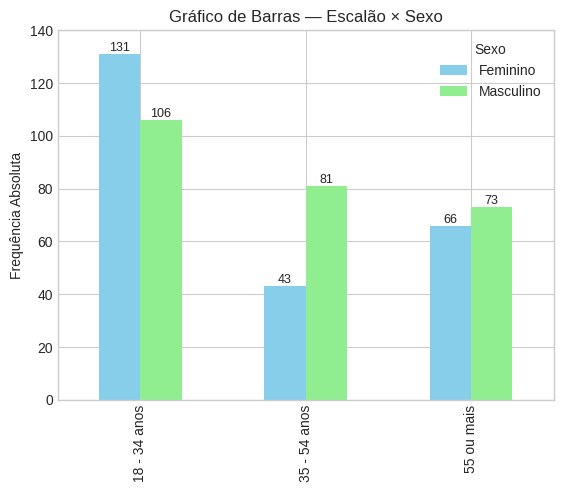

In [ ]:
# --------------------------------------------------
# 5️⃣ Gráficos
# --------------------------------------------------
plt.style.use('seaborn-v0_8-whitegrid')
cores_escalao = ["skyblue", "lightgreen", "salmon"]
cores_sexo = ["lightgreen", "salmon"]


# --------------------------------------------------
# G1 — Barras lado a lado (Escalão × Sexo)
# --------------------------------------------------
ax = tab.plot(kind='bar', color=cores_escalao)
plt.title("Gráfico de Barras — Escalão × Sexo")
plt.ylabel("Frequência Absoluta")
plt.xlabel("")
plt.ylim(0, 140)
plt.legend(title="Sexo", loc='upper right')

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=9)
plt.show()

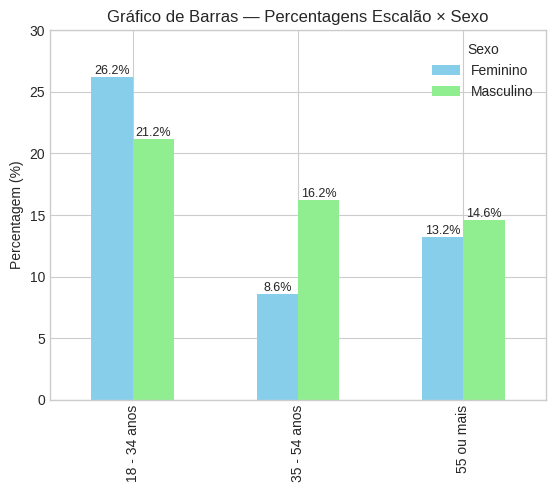

In [ ]:
# --------------------------------------------------
# G2 — Barras (% total) Escalão × Sexo
# --------------------------------------------------
ax = prop_total.plot(kind='bar', color=cores_escalao)
plt.title("Gráfico de Barras — Percentagens Escalão × Sexo")
plt.ylabel("Percentagem (%)")
plt.xlabel("")
plt.ylim(0, 30)
plt.legend(title="Sexo", loc='upper right')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='edge', fontsize=9)
plt.show()

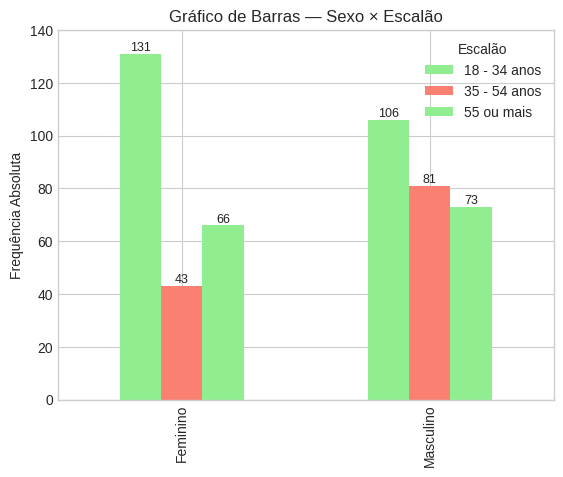

In [ ]:
# --------------------------------------------------
# G3 — Barras (Sexo × Escalão)
# --------------------------------------------------
ax = tab_inv.plot(kind='bar', color=cores_sexo)
plt.title("Gráfico de Barras — Sexo × Escalão")
plt.ylabel("Frequência Absoluta")
plt.xlabel("")
plt.ylim(0, 140)
plt.legend(title="Escalão", loc='upper right')

for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=9)
plt.show()

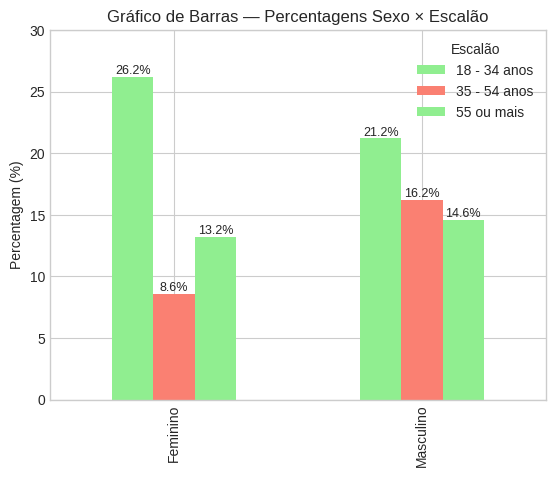

In [ ]:
# --------------------------------------------------
# G4 — Barras (% total) Sexo × Escalão
# --------------------------------------------------
ax = prop_total_inv.plot(kind='bar', color=cores_sexo)
plt.title("Gráfico de Barras — Percentagens Sexo × Escalão")
plt.ylabel("Percentagem (%)")
plt.xlabel("")
plt.ylim(0, 30)
plt.legend(title="Escalão", loc='upper right')

for container in ax.containers:
    ax.bar_label(container, fmt='%.1f%%', label_type='edge', fontsize=9)
plt.show()

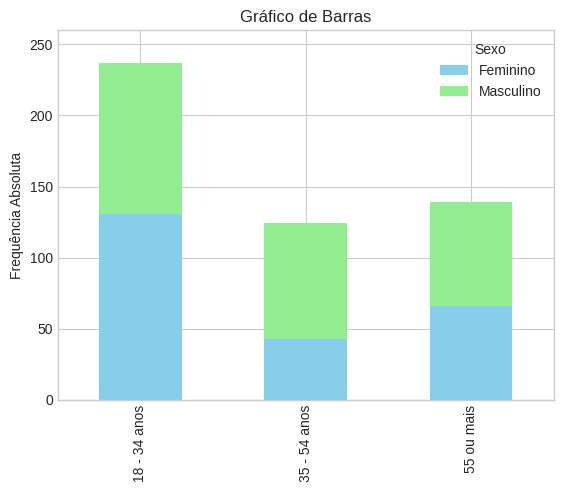

In [ ]:
# ------------------------------------------------------------
# 1️⃣ Barras empilhadas (stacked = True)
# ------------------------------------------------------------
ax = tab.plot(kind='bar', stacked=True, color=cores_escalao)
plt.title("Gráfico de Barras")
plt.xlabel("")
plt.ylabel("Frequência Absoluta")
plt.ylim(0, 260) # Adjusted y-limit to accommodate stacked bars
plt.show()

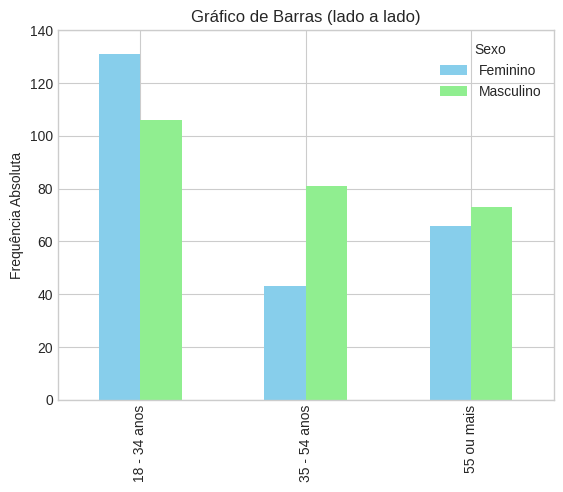

In [ ]:
# ------------------------------------------------------------
# 2️⃣ Barras lado a lado (stacked = False)
# ------------------------------------------------------------
ax = tab.plot(kind='bar', stacked=False, color=cores_escalao)
plt.title("Gráfico de Barras (lado a lado)")
plt.xlabel("")
plt.ylabel("Frequência Absoluta")
plt.ylim(0, 140)
plt.show()

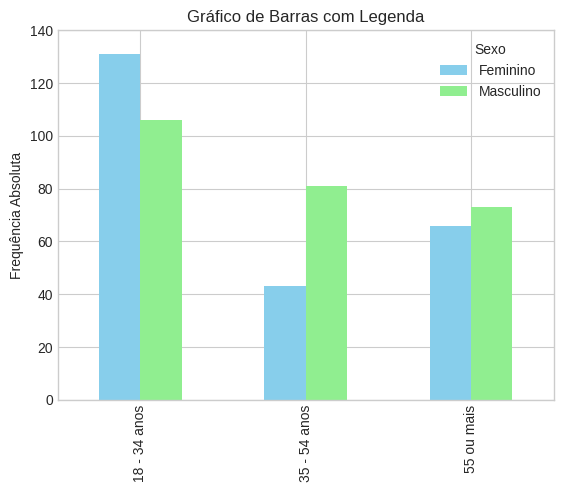

In [ ]:
ax = tab.plot(kind='bar', stacked=False, color=cores_escalao)
plt.title("Gráfico de Barras com Legenda")
plt.xlabel("")
plt.ylabel("Frequência Absoluta")
plt.ylim(0, 140)
plt.legend(title="Sexo", loc='upper right')
plt.show()